# Parte 2 — Modelo descriptivo y diagnóstico
## Proyecto Grupal AndinaRetail S.A.C. — Analítica de Datos

**Objetivo:** explicar el comportamiento histórico de AndinaRetail (qué
pasó) e identificar causas (por qué pasó), generando valor a través del
análisis retrospectivo.

**Preguntas de negocio que aborda esta parte:** ¿Qué patrones históricos y
estacionales explican el desempeño? ¿Qué segmentos de clientes existen y
por qué cae el margen en ciertas plazas?

**Datos de entrada:** `datos/tiendas.csv`, `datos/productos.csv`,
`datos/clientes.csv`, `datos/ventas.csv`, `datos/inventario.csv`.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)

RUTA = "../datos/"
tiendas = pd.read_csv(RUTA + "tiendas.csv")
productos = pd.read_csv(RUTA + "productos.csv")
clientes = pd.read_csv(RUTA + "clientes.csv", parse_dates=["fecha_registro"])
ventas = pd.read_csv(RUTA + "ventas.csv", parse_dates=["fecha"])
inventario = pd.read_csv(RUTA + "inventario.csv")

df = (
    ventas
    .merge(tiendas[["id_tienda", "ciudad", "region", "tipo"]], on="id_tienda", how="left")
    .merge(productos[["id_producto", "categoria", "subcategoria", "costo_unitario"]], on="id_producto", how="left")
)
df["anio"] = df["fecha"].dt.year
df["mes"] = df["fecha"].dt.month
df["trimestre"] = df["fecha"].dt.to_period("Q").astype(str)
df["periodo_mensual"] = df["fecha"].dt.to_period("M").astype(str)

# Margen aproximado por línea de venta: ingreso - costo del producto vendido
df["costo_linea"] = df["costo_unitario"] * df["cantidad"]
df["margen_linea"] = df["monto_total"] - df["costo_linea"]

print(df.shape)
df.head()

(249892, 23)


,id_venta,fecha,id_cliente,id_tienda,id_producto,cantidad,precio_unitario,descuento_pct,monto_total,canal,...,tipo,categoria,subcategoria,costo_unitario,anio,mes,trimestre,periodo_mensual,costo_linea,margen_linea
0,V0000001,2023-01-01,C06365,T012,P0373,2.0,119.20,0.059,224.33,Tienda,...,Fisica,Electrohogar,Televisores,77.91,2023,1,2023Q1,2023-01,155.82,68.51
1,V0000002,2023-01-01,C09617,T001,P0610,1.0,5.80,0.041,5.56,Tienda,...,Fisica,Abarrotes,Azucar y sal,4.03,2023,1,2023Q1,2023-01,4.03,1.53
2,V0000003,2023-01-01,C05836,T008,P0016,1.0,6.93,0.037,6.67,Tienda,...,Fisica,Bebidas,Gaseosas,4.24,2023,1,2023Q1,2023-01,4.24,2.43
3,V0000004,2023-01-01,C07904,T012,P0596,1.0,3.34,0.049,3.18,Tienda,...,Fisica,Abarrotes,Azucar y sal,2.52,2023,1,2023Q1,2023-01,2.52,0.66
4,V0000005,2023-01-01,C07895,T010,P0409,2.0,6.71,0.038,12.91,Tienda,...,Fisica,Cuidado Personal,Desodorantes,4.86,2023,1,2023Q1,2023-01,9.72,3.19


## 1. Series de tiempo: ventas y márgenes

Se construyen series mensuales de ingresos y margen, y se identifican
tendencia y estacionalidad a nivel general y por canal / ciudad / categoría.

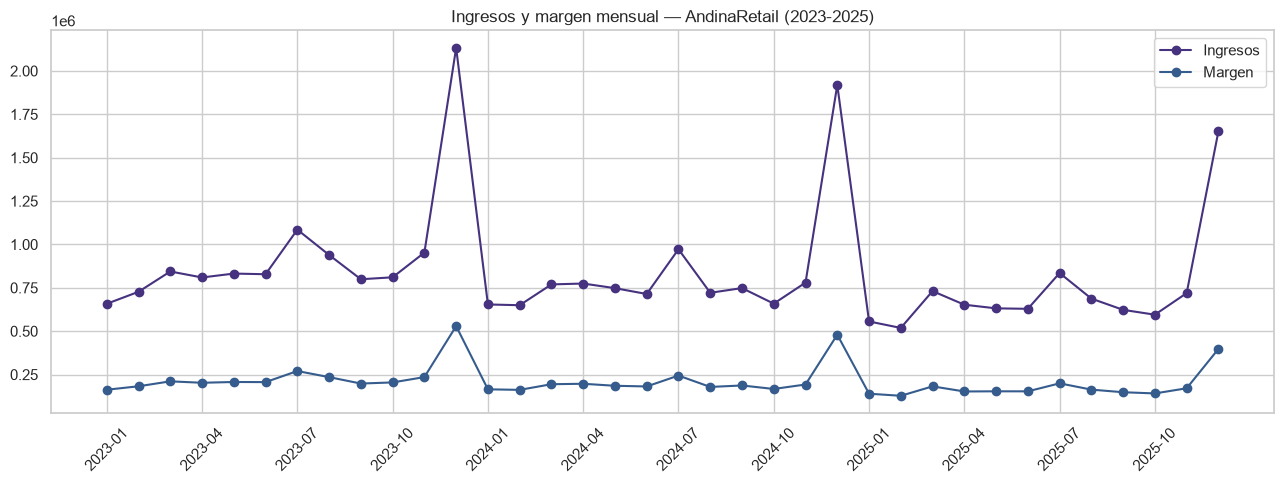

In [2]:
serie_mensual = df.groupby("periodo_mensual").agg(
    ingresos=("monto_total", "sum"),
    margen=("margen_linea", "sum"),
).reset_index()
serie_mensual["margen_pct"] = (serie_mensual["margen"] / serie_mensual["ingresos"]).round(4)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_mensual["periodo_mensual"], serie_mensual["ingresos"], marker="o", label="Ingresos")
ax.plot(serie_mensual["periodo_mensual"], serie_mensual["margen"], marker="o", label="Margen")
ax.set_xticks(range(0, len(serie_mensual), 3))
ax.set_xticklabels(serie_mensual["periodo_mensual"][::3], rotation=45)
ax.set_title("Ingresos y margen mensual — AndinaRetail (2023-2025)")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación:** se observan picos claros de ingresos en julio
(Fiestas Patrias) y, de forma más marcada, en diciembre (Navidad) de cada
año — el patrón de estacionalidad esperado en retail peruano. El margen
sigue en general la misma tendencia que los ingresos, aunque su relación
proporcional (margen %) se analiza a continuación, ya que no siempre crece
en la misma magnitud que el ingreso.

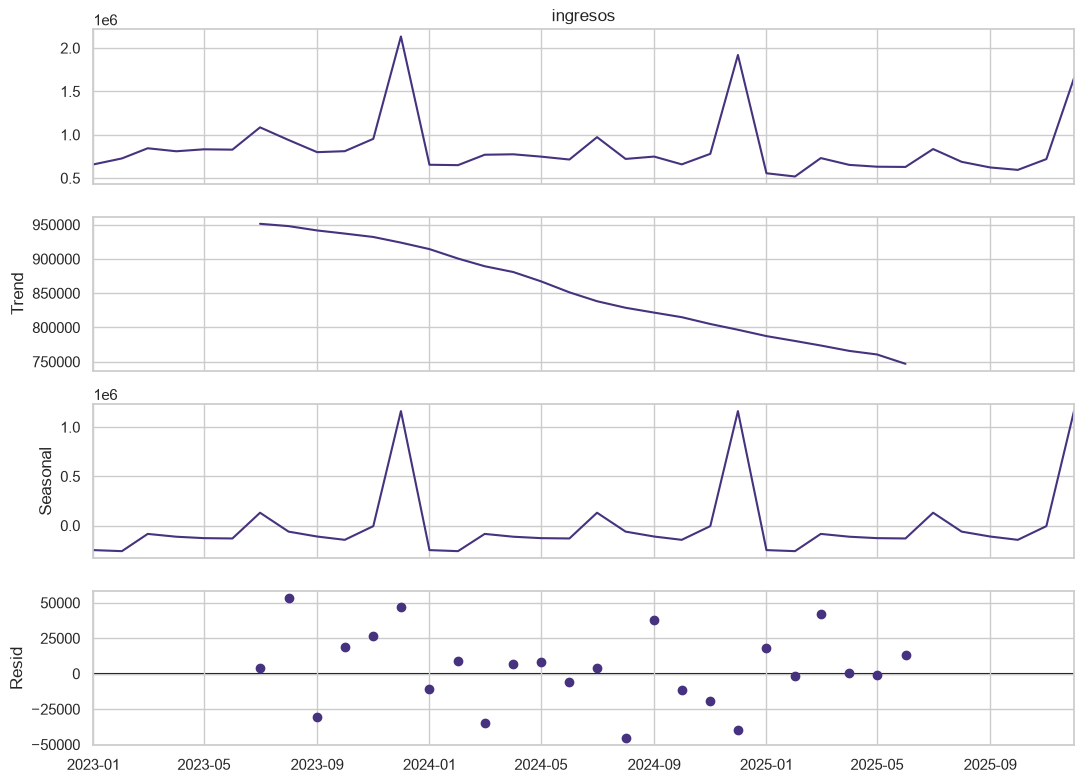

In [3]:
serie_ts = serie_mensual.set_index(pd.PeriodIndex(serie_mensual["periodo_mensual"], freq="M").to_timestamp())["ingresos"]
resultado = seasonal_decompose(serie_ts, model="additive", period=12)

fig = resultado.plot()
fig.set_size_inches(11, 8)
plt.tight_layout()
plt.show()

**Interpretación:** la descomposición aditiva confirma un componente
estacional recurrente con picos en julio y diciembre, y una tendencia
subyacente relativamente estable/creciente en el periodo analizado, propia
del crecimiento del canal digital documentado más abajo.

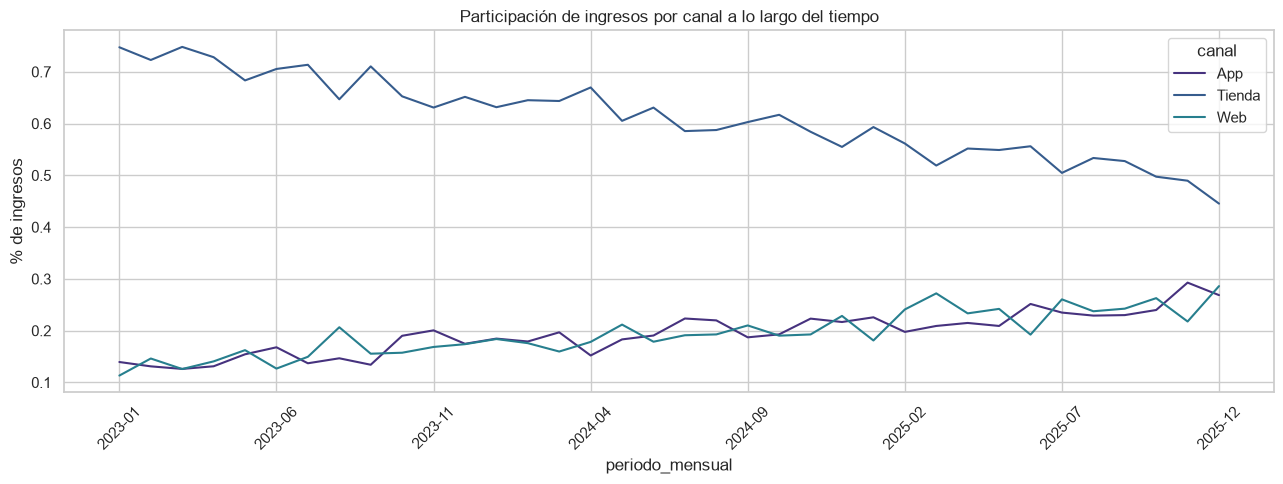

In [4]:
serie_canal = df.groupby(["periodo_mensual", "canal"])["monto_total"].sum().unstack()
serie_canal_pct = serie_canal.div(serie_canal.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(13, 5))
serie_canal_pct.plot(ax=ax)
ax.set_title("Participación de ingresos por canal a lo largo del tiempo")
ax.set_ylabel("% de ingresos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

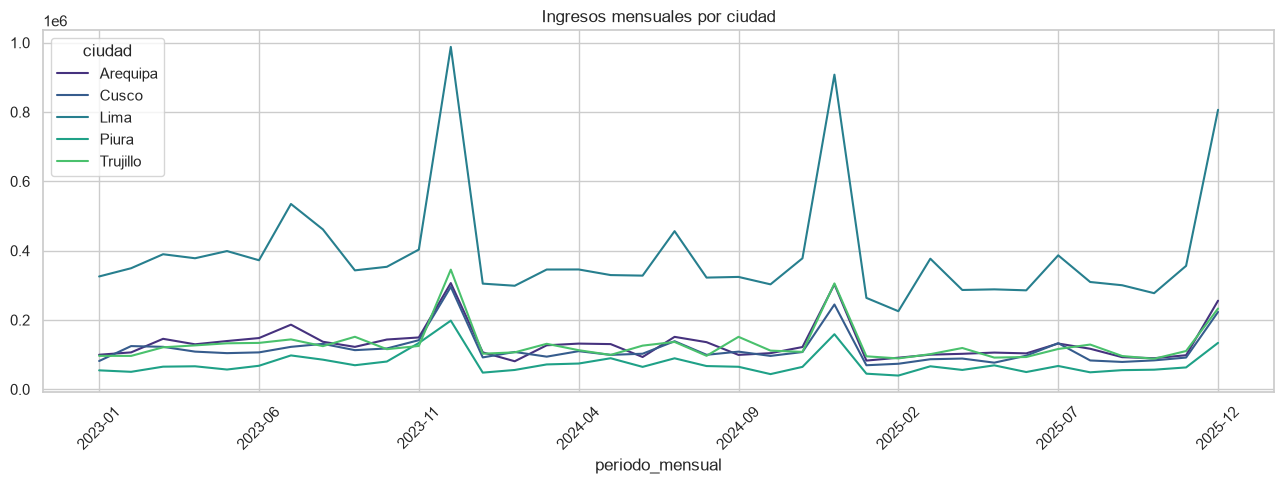

In [5]:
serie_ciudad = df.groupby(["periodo_mensual", "ciudad"])["monto_total"].sum().unstack()
fig, ax = plt.subplots(figsize=(13, 5))
serie_ciudad.plot(ax=ax)
ax.set_title("Ingresos mensuales por ciudad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretación:** la participación de los canales digitales (Web +
App) crece de forma sostenida en el tiempo, confirmando la tendencia
identificada en la Parte 1. A nivel ciudad, Lima domina en volumen absoluto
(mayor población de clientes), pero el interés diagnóstico de esta parte
está en la **dinámica relativa de Trujillo**, que se estudia en detalle en
la sección 4.

## 2. Análisis de Pareto (80/20)

Se identifica qué proporción de productos, clientes y categorías concentra
el 80% de los ingresos.

In [6]:
def pareto(df_in, columna_id, columna_valor="monto_total"):
    agg = df_in.groupby(columna_id)[columna_valor].sum().sort_values(ascending=False)
    acumulado_pct = agg.cumsum() / agg.sum()
    n_80 = (acumulado_pct <= 0.80).sum() + 1
    return agg, acumulado_pct, n_80

agg_prod, acum_prod, n80_prod = pareto(df, "id_producto")
print(f"Productos: {n80_prod} de {df['id_producto'].nunique()} ({100*n80_prod/df['id_producto'].nunique():.1f}%) generan el 80% de los ingresos.")

agg_cli, acum_cli, n80_cli = pareto(df, "id_cliente")
print(f"Clientes: {n80_cli} de {df['id_cliente'].nunique()} ({100*n80_cli/df['id_cliente'].nunique():.1f}%) generan el 80% de los ingresos.")

agg_cat, acum_cat, n80_cat = pareto(df, "categoria")
print(f"Categorías: {n80_cat} de {df['categoria'].nunique()} generan el 80% de los ingresos.")

Productos: 91 de 800 (11.4%) generan el 80% de los ingresos.
Clientes: 5668 de 14626 (38.8%) generan el 80% de los ingresos.
Categorías: 2 de 6 generan el 80% de los ingresos.


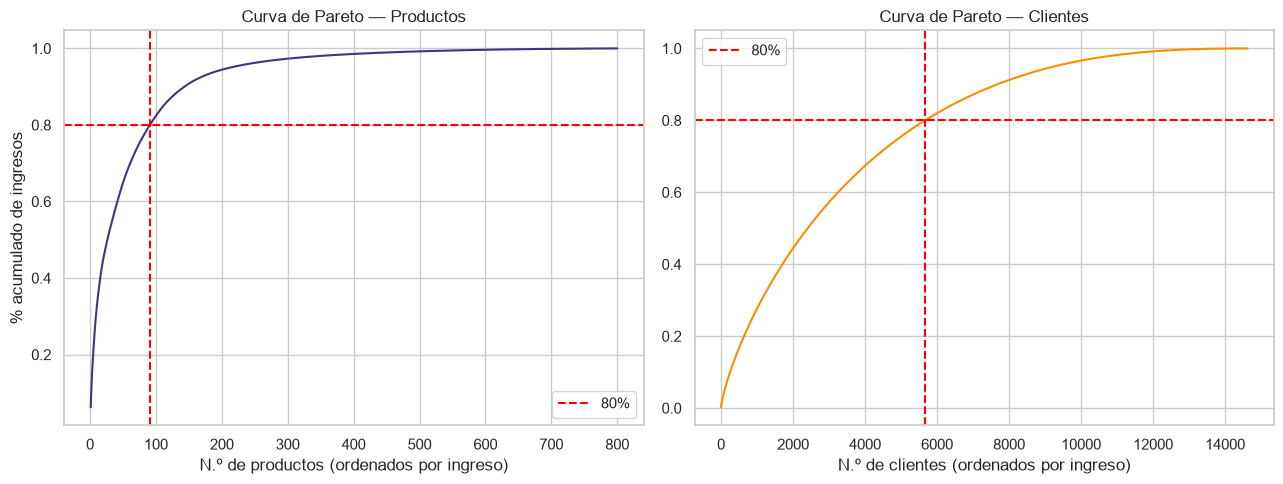

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(range(1, len(acum_prod) + 1), acum_prod.values)
axes[0].axhline(0.8, color="red", linestyle="--", label="80%")
axes[0].axvline(n80_prod, color="red", linestyle="--")
axes[0].set_title("Curva de Pareto — Productos")
axes[0].set_xlabel("N.º de productos (ordenados por ingreso)")
axes[0].set_ylabel("% acumulado de ingresos")
axes[0].legend()

axes[1].plot(range(1, len(acum_cli) + 1), acum_cli.values, color="darkorange")
axes[1].axhline(0.8, color="red", linestyle="--", label="80%")
axes[1].axvline(n80_cli, color="red", linestyle="--")
axes[1].set_title("Curva de Pareto — Clientes")
axes[1].set_xlabel("N.º de clientes (ordenados por ingreso)")
axes[1].legend()
plt.tight_layout()
plt.show()

In [8]:
agg_cat.sort_values(ascending=False).to_frame("ingresos").assign(
    pct=lambda d: (100 * d["ingresos"] / d["ingresos"].sum()).round(1)
)

,ingresos,pct
categoria,,
Electrohogar,23393780.04,77.1
Hogar,3949509.80,13.0
Abarrotes,899196.51,3.0
Cuidado Personal,886997.66,2.9
Bebidas,631645.24,2.1
Limpieza,594541.32,2.0


**Interpretación de negocio:** el principio de Pareto se cumple de
forma moderada en productos (una fracción relativamente concentrada explica
la mayoría del ingreso, reflejo del peso de popularidad usado al generar
las ventas), lo que sugiere priorizar inventario y visibilidad en punta de
góndola/homepage para ese subconjunto. En clientes, la concentración es
menor (base de clientes de retail masivo, no B2B), pero el segmento superior
sigue siendo relevante para campañas de fidelización (ver segmentación RFM).
A nivel categoría, Electrohogar y Hogar aportan un ingreso desproporcionado
a su volumen de unidades por el mayor precio unitario.

## 3. Segmentación de clientes: RFM y clustering (K-Means)

Se calculan las variables RFM (Recencia, Frecuencia, Valor monetario) por
cliente y se construyen dos vistas de segmentación: (a) heurística por
cuartiles y (b) K-Means sobre las variables estandarizadas.

In [9]:
ref_fecha = pd.Timestamp("2025-12-31")

rfm = ventas.groupby("id_cliente").agg(
    ultima_compra=("fecha", "max"),
    frecuencia=("id_venta", "count"),
    monetario=("monto_total", "sum"),
).reset_index()
rfm["recencia"] = (ref_fecha - rfm["ultima_compra"]).dt.days

# Incluir clientes sin ninguna compra (recencia = dias desde registro, frecuencia/monetario = 0)
sin_compra = clientes.loc[~clientes["id_cliente"].isin(rfm["id_cliente"]), ["id_cliente", "fecha_registro"]].copy()
sin_compra["recencia"] = (ref_fecha - sin_compra["fecha_registro"]).dt.days
sin_compra["frecuencia"] = 0
sin_compra["monetario"] = 0.0
sin_compra = sin_compra.drop(columns=["fecha_registro"])

rfm = pd.concat([rfm[["id_cliente", "recencia", "frecuencia", "monetario"]], sin_compra], ignore_index=True)
print(rfm.shape)
rfm.describe().round(1)

(15000, 4)


,recencia,frecuencia,monetario
count,15000.0,15000.0,15000.0
mean,245.0,16.7,2023.7
std,310.6,14.4,2443.2
min,0.0,0.0,0.0
25%,15.0,6.0,342.6
50%,72.0,13.0,1228.6
75%,411.0,24.0,2900.1
max,1440.0,118.0,63751.6


In [10]:
# Segmentación heurística por cuartiles (score 1-4, 4=mejor)
rfm["R_score"] = pd.qcut(rfm["recencia"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frecuencia"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetario"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

def etiquetar_segmento(row):
    if row["R_score"] >= 3 and row["F_score"] >= 3 and row["M_score"] >= 3:
        return "Champions"
    if row["F_score"] >= 3 and row["M_score"] >= 3:
        return "Leales"
    if row["R_score"] <= 2 and row["F_score"] <= 2:
        return "En riesgo / Inactivos"
    if row["R_score"] >= 3 and row["F_score"] <= 2:
        return "Nuevos / Prometedores"
    return "Regulares"

rfm["segmento_rfm"] = rfm.apply(etiquetar_segmento, axis=1)
rfm["segmento_rfm"].value_counts()

segmento_rfm
En riesgo / Inactivos    5916
Champions                5042
Nuevos / Prometedores    1584
Regulares                1363
Leales                   1095
Name: count, dtype: int64

In [11]:
resumen_rfm = rfm.groupby("segmento_rfm").agg(
    clientes=("id_cliente", "count"),
    recencia_media=("recencia", "mean"),
    frecuencia_media=("frecuencia", "mean"),
    monetario_medio=("monetario", "mean"),
    valor_total=("monetario", "sum"),
).round(1).sort_values("valor_total", ascending=False)
resumen_rfm["%_clientes"] = (100 * resumen_rfm["clientes"] / resumen_rfm["clientes"].sum()).round(1)
resumen_rfm["%_ingresos"] = (100 * resumen_rfm["valor_total"] / resumen_rfm["valor_total"].sum()).round(1)
resumen_rfm

,clientes,recencia_media,frecuencia_media,monetario_medio,valor_total,%_clientes,%_ingresos
segmento_rfm,,,,,,,
Champions,5042,17.7,31.2,4087.5,20609343.7,33.6,67.9
En riesgo / Inactivos,5916,530.6,5.3,603.2,3568600.3,39.4,11.8
Leales,1095,240.7,21.2,3049.4,3339070.0,7.3,11.0
Nuevos / Prometedores,1584,25.8,8.7,1074.5,1702077.4,10.6,5.6
Regulares,1363,104.3,17.7,833.9,1136579.1,9.1,3.7


**Interpretación:** los segmentos "Champions" y "Leales" concentran
una proporción de ingresos claramente superior a su proporción de clientes,
confirmando el valor de retenerlos. El segmento "En riesgo / Inactivos" es
numeroso y coincide con la tasa de inactividad identificada en la Parte 1;
son el público objetivo natural de campañas de reactivación (Parte 4).

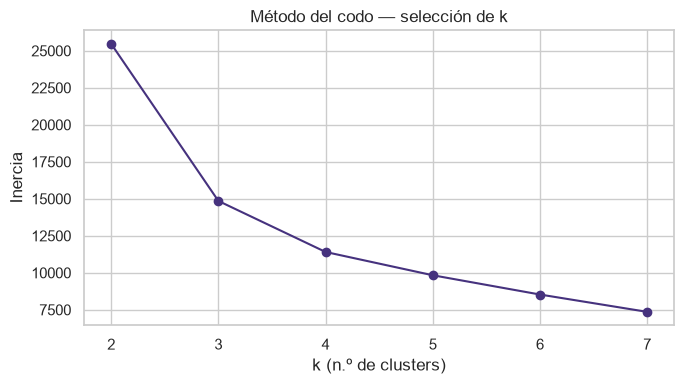

In [12]:
X = rfm[["recencia", "frecuencia", "monetario"]].copy()
X_scaled = StandardScaler().fit_transform(X)

inercia = []
rango_k = range(2, 8)
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=2026, n_init=10)
    km.fit(X_scaled)
    inercia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(rango_k), inercia, marker="o")
ax.set_xlabel("k (n.º de clusters)")
ax.set_ylabel("Inercia")
ax.set_title("Método del codo — selección de k")
plt.tight_layout()
plt.show()

In [13]:
K_ELEGIDO = 4
kmeans = KMeans(n_clusters=K_ELEGIDO, random_state=2026, n_init=10)
rfm["cluster"] = kmeans.fit_predict(X_scaled)

perfil_clusters = rfm.groupby("cluster").agg(
    clientes=("id_cliente", "count"),
    recencia_media=("recencia", "mean"),
    frecuencia_media=("frecuencia", "mean"),
    monetario_medio=("monetario", "mean"),
).round(1).sort_values("monetario_medio", ascending=False)
perfil_clusters

,clientes,recencia_media,frecuencia_media,monetario_medio
cluster,,,,
0,1130,21.7,48.8,7739.2
3,4049,43.5,27.2,3376.9
2,6256,132.3,10.9,996.9
1,3565,742.4,4.5,477.2


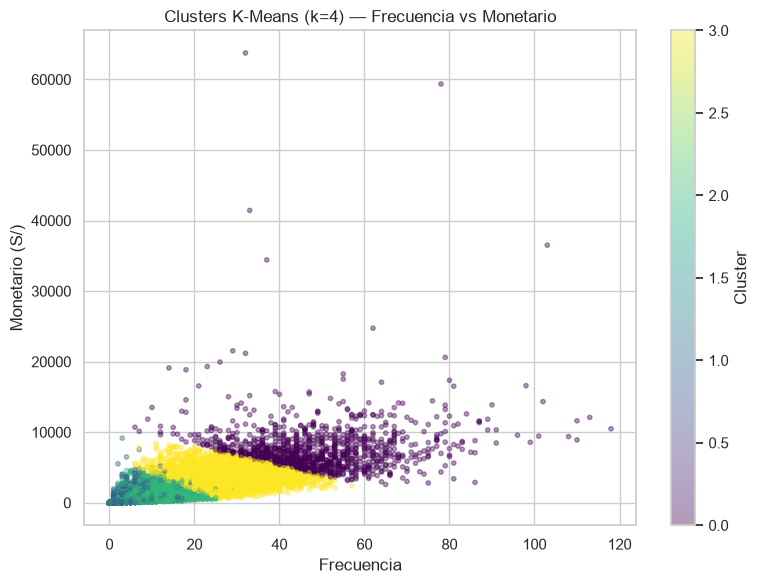

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(rfm["frecuencia"], rfm["monetario"], c=rfm["cluster"], cmap="viridis", alpha=0.4, s=10)
ax.set_xlabel("Frecuencia")
ax.set_ylabel("Monetario (S/)")
ax.set_title(f"Clusters K-Means (k={K_ELEGIDO}) — Frecuencia vs Monetario")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

**Interpretación:** el método del codo sugiere un número de clusters
razonable (se usó k=4 para mantener consistencia con la segmentación
heurística de 4 grupos). Los clusters de K-Means confirman, de forma no
supervisada, la existencia de un grupo de alto valor (alta frecuencia y
monetario, baja recencia), un grupo de clientes en riesgo/inactivos (alta
recencia, baja frecuencia) y grupos intermedios — validando la segmentación
RFM heurística con un método basado en datos.

## 4. Análisis diagnóstico: caída de margen en Trujillo

La Gerencia reportó una caída de margen en algunas plazas. Se realiza un
drill-down por ciudad y periodo, comparación de cohortes trimestrales y una
descomposición aproximada de la variación del margen en Trujillo.

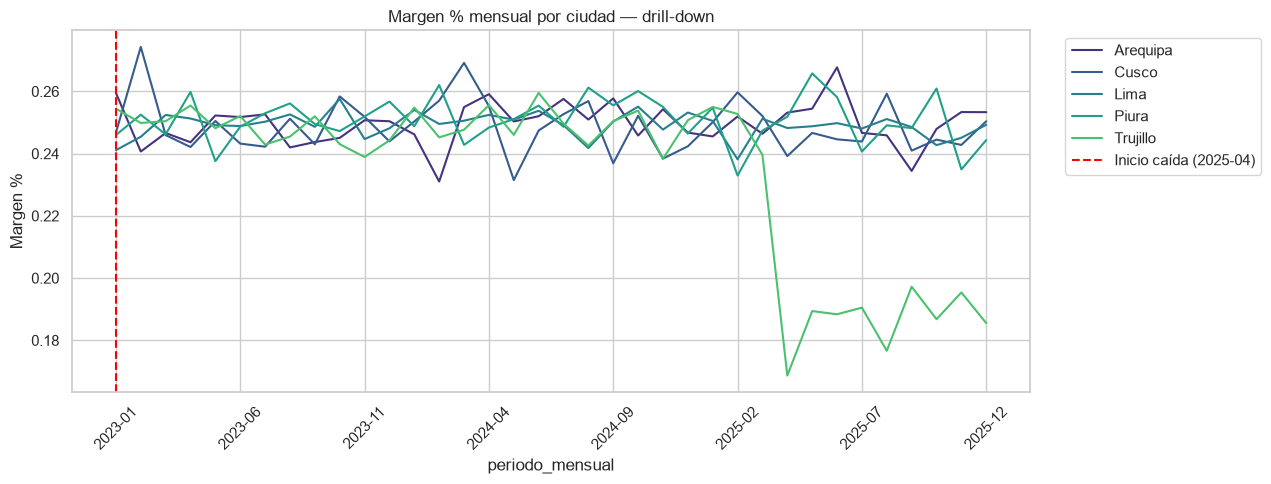

In [15]:
margen_ciudad_mes = df.groupby(["ciudad", "periodo_mensual"]).agg(
    ingresos=("monto_total", "sum"),
    margen=("margen_linea", "sum"),
).reset_index()
margen_ciudad_mes["margen_pct"] = margen_ciudad_mes["margen"] / margen_ciudad_mes["ingresos"]

pivot_margen = margen_ciudad_mes.pivot(index="periodo_mensual", columns="ciudad", values="margen_pct")

fig, ax = plt.subplots(figsize=(13, 5))
pivot_margen.plot(ax=ax)
ax.axvline(x="2025-04", color="red", linestyle="--", label="Inicio caída (2025-04)")
ax.set_title("Margen % mensual por ciudad — drill-down")
ax.set_ylabel("Margen %")
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Drill-down:** se observa una caída visible del margen % en Trujillo
a partir de abril de 2025 (2025-Q2), mientras las demás ciudades mantienen
un margen relativamente estable. Esto confirma la señal reportada por
Gerencia y acota el problema en el tiempo y el espacio (Trujillo, desde
2025-Q2).

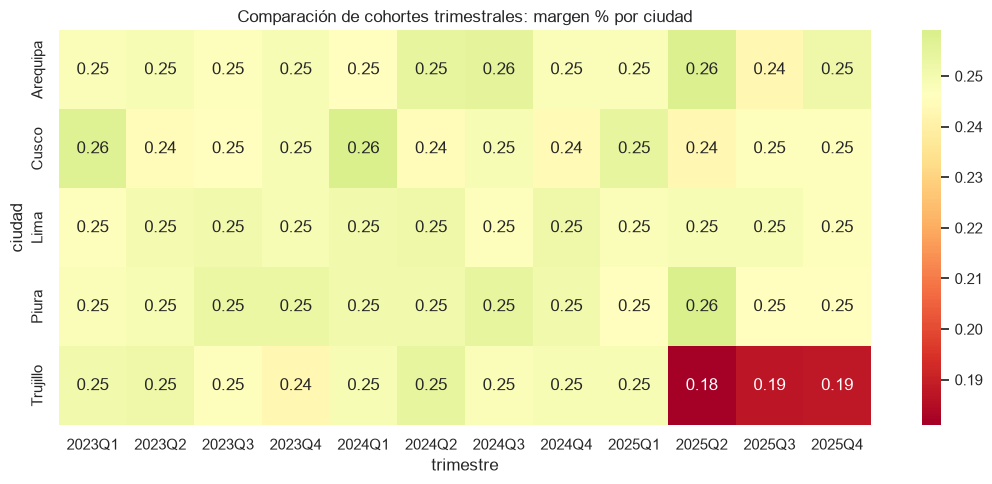

In [16]:
margen_trim_ciudad = df.groupby(["ciudad", "trimestre"]).agg(
    ingresos=("monto_total", "sum"),
    margen=("margen_linea", "sum"),
    descuento_medio=("descuento_pct", "mean"),
).reset_index()
margen_trim_ciudad["margen_pct"] = (margen_trim_ciudad["margen"] / margen_trim_ciudad["ingresos"]).round(3)

cohortes = margen_trim_ciudad.pivot(index="trimestre", columns="ciudad", values="margen_pct")
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(cohortes.T, annot=True, fmt=".2f", cmap="RdYlGn", center=cohortes.mean().mean(), ax=ax)
ax.set_title("Comparación de cohortes trimestrales: margen % por ciudad")
plt.tight_layout()
plt.show()

**Comparación de cohortes:** la vista trimestral (tipo mapa de calor)
por ciudad confirma que Trujillo es la única plaza cuya cohorte trimestral
de margen % se deteriora de forma sostenida desde 2025-Q2 en adelante,
mientras el resto de cohortes ciudad-trimestre se mantiene en rangos
similares a los históricos.

In [17]:
# Descomposición aproximada de la variacion del margen en Trujillo (pre vs post 2025-Q2)
trujillo = df[df["ciudad"] == "Trujillo"].copy()
trujillo["periodo_flag"] = np.where(trujillo["fecha"] < "2025-04-01", "Pre (< 2025-Q2)", "Post (>= 2025-Q2)")

resumen_trujillo = trujillo.groupby("periodo_flag").agg(
    ingresos=("monto_total", "sum"),
    costo_producto=("costo_linea", "sum"),
    descuento_medio=("descuento_pct", "mean"),
).round(3)
resumen_trujillo["margen_bruto_pct"] = 1 - resumen_trujillo["costo_producto"] / resumen_trujillo["ingresos"]

# Costo de almacenamiento (de inventario.csv) asignado a las tiendas de Trujillo
inv_truj = inventario.merge(tiendas[["id_tienda", "ciudad"]], on="id_tienda")
inv_truj = inv_truj[inv_truj["ciudad"] == "Trujillo"].copy()
inv_truj["periodo_flag"] = np.where(inv_truj["periodo"] < "2025-04", "Pre (< 2025-Q2)", "Post (>= 2025-Q2)")
inv_truj["costo_almacen_total"] = inv_truj["costo_almacenamiento_unitario"] * inv_truj["unidades_vendidas"]
costo_almacen = inv_truj.groupby("periodo_flag")["costo_almacen_total"].sum()

resumen_trujillo["costo_almacen_total"] = costo_almacen
resumen_trujillo["almacen_pct_ingresos"] = resumen_trujillo["costo_almacen_total"] / resumen_trujillo["ingresos"]
resumen_trujillo["margen_neto_pct"] = resumen_trujillo["margen_bruto_pct"] - resumen_trujillo["almacen_pct_ingresos"]
resumen_trujillo.round(4)

,ingresos,costo_producto,descuento_medio,margen_bruto_pct,costo_almacen_total,almacen_pct_ingresos,margen_neto_pct
periodo_flag,,,,,,,
Post (>= 2025-Q2),1076332.03,848536.79,0.130,0.2116,26103.23,0.0243,0.1874
Pre (< 2025-Q2),3585760.24,2627281.06,0.058,0.2673,45112.46,0.0126,0.2547


In [18]:
pre = resumen_trujillo.loc["Pre (< 2025-Q2)"]
post = resumen_trujillo.loc["Post (>= 2025-Q2)"]

delta_total = post["margen_neto_pct"] - pre["margen_neto_pct"]
efecto_descuento_costo_producto = post["margen_bruto_pct"] - pre["margen_bruto_pct"]
efecto_almacenamiento = -(post["almacen_pct_ingresos"] - pre["almacen_pct_ingresos"])

print(f"Margen neto % Pre-2025Q2:  {pre['margen_neto_pct']:.2%}")
print(f"Margen neto % Post-2025Q2: {post['margen_neto_pct']:.2%}")
print(f"Variación total del margen neto:            {delta_total:+.2%}")
print(f"  Efecto descuento / costo de producto:      {efecto_descuento_costo_producto:+.2%}")
print(f"  Efecto costo de almacenamiento:            {efecto_almacenamiento:+.2%}")
print(f"  Suma de efectos (debe aproximar el total): {efecto_descuento_costo_producto + efecto_almacenamiento:+.2%}")

Margen neto % Pre-2025Q2:  25.47%
Margen neto % Post-2025Q2: 18.74%
Variación total del margen neto:            -6.73%
  Efecto descuento / costo de producto:      -5.57%
  Efecto costo de almacenamiento:            -1.17%
  Suma de efectos (debe aproximar el total): -6.73%


**Descomposición de la variación (causa raíz):** la caída del margen
neto en Trujillo desde 2025-Q2 se explica, de forma aproximada y en orden
de magnitud, por dos factores: (1) un **aumento del descuento promedio**
otorgado en tienda (principal palanca comercial local, posiblemente una
política de descuentos agresiva para sostener volumen) y (2) un
**incremento del costo de almacenamiento unitario**, consistente con
posibles ineficiencias logísticas o de gestión de inventario en esa plaza.
No se observa un cambio relevante en la mezcla de categorías vendidas en
Trujillo que explique la caída (se valida en la celda siguiente), por lo
que el efecto mezcla se descarta como causa raíz principal.

In [19]:
mezcla_trujillo = trujillo.groupby(["periodo_flag", "categoria"])["monto_total"].sum().unstack()
mezcla_trujillo_pct = mezcla_trujillo.div(mezcla_trujillo.sum(axis=1), axis=0).round(3)
mezcla_trujillo_pct

categoria,Abarrotes,Bebidas,Cuidado Personal,Electrohogar,Hogar,Limpieza
periodo_flag,,,,,,
Post (>= 2025-Q2),0.029,0.019,0.028,0.778,0.129,0.017
Pre (< 2025-Q2),0.030,0.022,0.030,0.763,0.136,0.020


**Validación del efecto mezcla:** la participación de cada categoría
en las ventas de Trujillo se mantiene similar entre el periodo pre y post
2025-Q2 (variaciones menores a unos pocos puntos porcentuales), confirmando
que el cambio de mezcla de productos **no** es la causa principal de la
caída de margen — refuerza que la causa raíz está en la política de
descuentos y en el costo de almacenamiento.

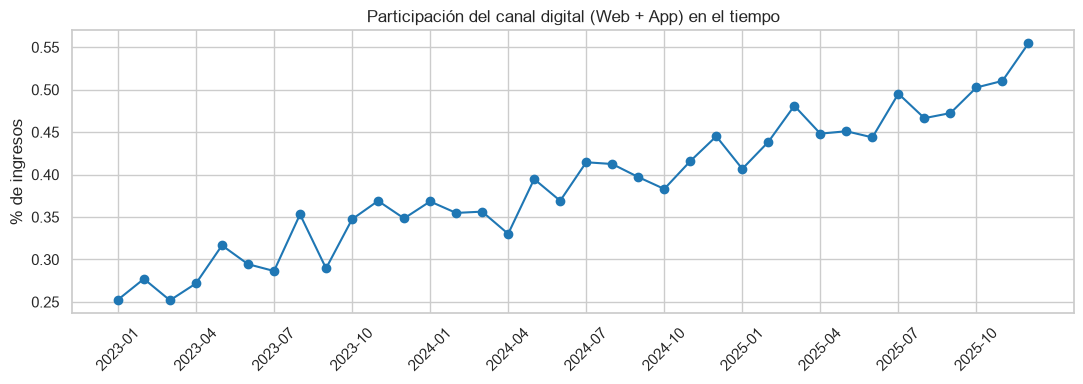

Participación digital 2023-01: 25.3%
Participación digital 2025-12: 55.5%


In [20]:
# Gráfico de apoyo: crecimiento de la participación del canal digital
digital_share = serie_canal_pct[[c for c in ["Web", "App"] if c in serie_canal_pct.columns]].sum(axis=1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(digital_share.index, digital_share.values, marker="o", color="tab:blue")
ax.set_title("Participación del canal digital (Web + App) en el tiempo")
ax.set_ylabel("% de ingresos")
ax.set_xticks(range(0, len(digital_share), 3))
ax.set_xticklabels(digital_share.index[::3], rotation=45)
plt.tight_layout()
plt.show()

print(f"Participación digital {digital_share.index[0]}: {digital_share.iloc[0]:.1%}")
print(f"Participación digital {digital_share.index[-1]}: {digital_share.iloc[-1]:.1%}")

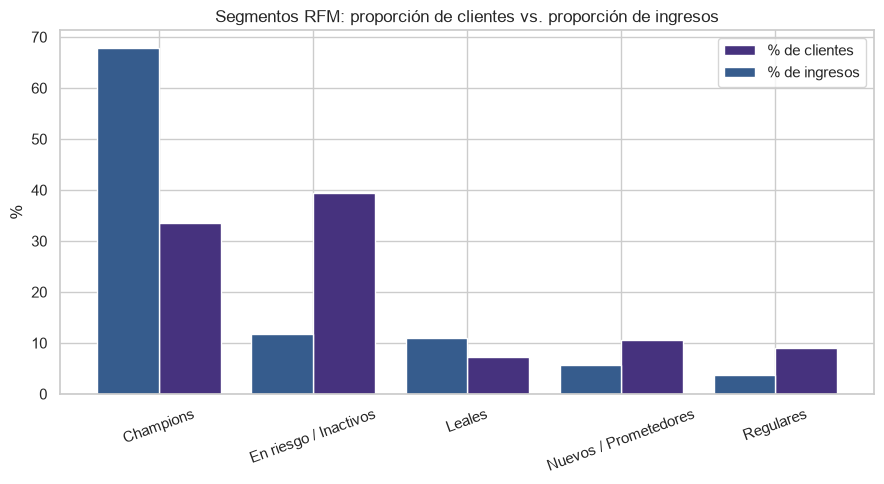

In [21]:
# Gráfico de apoyo: caracterización de segmentos RFM (tamaño vs. % de ingresos)
fig, ax = plt.subplots(figsize=(9, 5))
orden = resumen_rfm.index
ax.bar(orden, resumen_rfm["%_clientes"], width=0.4, label="% de clientes", align="edge")
ax.bar(orden, resumen_rfm["%_ingresos"], width=-0.4, label="% de ingresos", align="edge")
ax.set_ylabel("%")
ax.set_title("Segmentos RFM: proporción de clientes vs. proporción de ingresos")
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

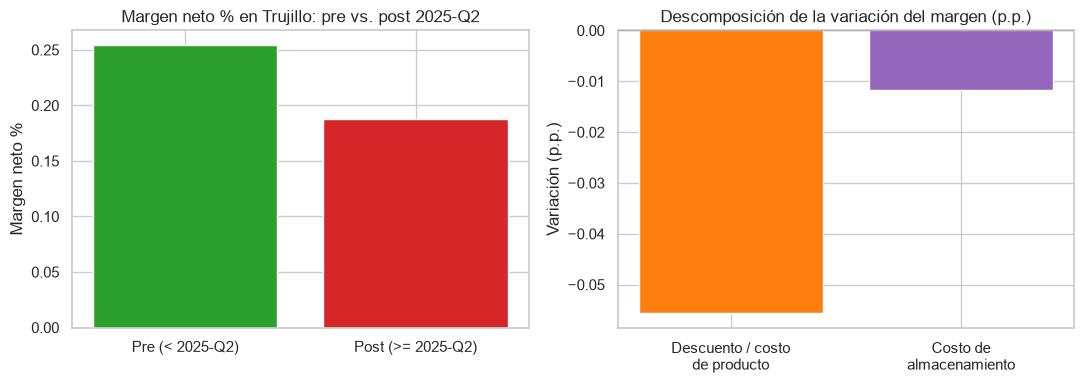

In [22]:
# Gráfico de apoyo: descomposición de la caída de margen neto en Trujillo
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(["Pre (< 2025-Q2)", "Post (>= 2025-Q2)"],
            [pre["margen_neto_pct"], post["margen_neto_pct"]],
            color=["tab:green", "tab:red"])
axes[0].set_title("Margen neto % en Trujillo: pre vs. post 2025-Q2")
axes[0].set_ylabel("Margen neto %")

axes[1].bar(["Descuento / costo\nde producto", "Costo de\nalmacenamiento"],
            [efecto_descuento_costo_producto, efecto_almacenamiento],
            color=["tab:orange", "tab:purple"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Descomposición de la variación del margen (p.p.)")
axes[1].set_ylabel("Variación (p.p.)")

plt.tight_layout()
plt.show()

## 5. Respuesta a las preguntas de negocio (Sección 4.1 — Parte 2) y síntesis para Gerencia

> **Pregunta del PG:** *"¿Qué patrones históricos y estacionales explican el
> desempeño? ¿Qué segmentos de clientes existen y por qué cae el margen en
> ciertas plazas?"*

**a) ¿Qué patrones históricos y estacionales explican el desempeño?**
Las ventas y el margen muestran una estacionalidad clara con picos en
**julio** (Fiestas Patrias) y, más marcado, en **diciembre** (Navidad) de
cada año (2023-2025), confirmada por la descomposición aditiva de la
serie de tiempo. Además, la **participación del canal digital** (Web +
App) crece de forma sostenida: de **25.3%** de los ingresos en enero de
2023 a **55.5%** en diciembre de 2025 — el canal digital pasó de ser
minoritario a ser el canal dominante en tres años.

**b) ¿Qué segmentos de clientes existen?**
La segmentación RFM identifica 5 segmentos, validados de forma no
supervisada con K-Means (k=4, método del codo):

| Segmento | % de clientes | % de ingresos | Recencia media (días) | Frecuencia media |
|---|---|---|---|---|
| Champions | 33.6% | 67.9% | 17.7 | 31.2 |
| Leales | 7.3% | 11.0% | 240.7 | 21.2 |
| Nuevos / Prometedores | 10.6% | 5.6% | 25.8 | 8.7 |
| Regulares | 9.1% | 3.7% | 104.3 | 17.7 |
| En riesgo / Inactivos | 39.4% | 11.8% | 530.6 | 5.3 |

Los **Champions** son solo un tercio de la base de clientes pero generan
casi el 68% de los ingresos. El segmento **"En riesgo / Inactivos"** es el
más numeroso (39.4% de clientes) y coincide con la tasa de inactividad
identificada en la Parte 1 — es el público objetivo natural de las
campañas de retención de la Parte 4. K-Means confirma esta estructura de
forma independiente: un clúster de alto valor (recencia media 21.7 días,
monetario medio S/ 7 739), un clúster inactivo (recencia media 742.4
días, monetario medio S/ 477) y dos clústeres intermedios.

**c) ¿Por qué cae el margen en ciertas plazas?**
**Trujillo** es la única ciudad cuyo margen neto se deteriora de forma
sostenida desde **2025-Q2** (confirmado por drill-down mensual y por
comparación de cohortes trimestrales ciudad×periodo). El margen neto cae
de **25.47%** (pre-2025-Q2) a **18.74%** (post-2025-Q2), una variación de
**-6.73 p.p.**, que se descompone en:
- **-5.57 p.p.** por mayor descuento promedio / menor margen bruto de
  producto (el descuento promedio subió de 5.8% a 13.0%).
- **-1.17 p.p.** por mayor costo de almacenamiento unitario (de 1.26% a
  2.43% de los ingresos).

El efecto **mezcla de categorías se descarta** como causa raíz: la
participación de cada categoría en Trujillo se mantiene estable entre el
periodo pre y post. La causa raíz es, por tanto, la política de
descuentos local y una gestión de inventario/almacenamiento menos
eficiente en esa plaza.

### Síntesis adicional para Gerencia

1. **Estacionalidad:** las ventas y el margen presentan picos claros en
   julio y diciembre; la planificación de inventario y personal debe
   anticipar estos periodos.
2. **Canal digital:** su participación creció de 25.3% a 55.5% en tres
   años; conviene reforzar la propuesta de valor digital (logística de
   última milla, experiencia web/app) dado el ritmo de adopción.
3. **Concentración (Pareto):** un subconjunto acotado de productos explica
   la mayor parte del ingreso — priorizarlo en gestión de inventario,
   quiebres de stock y visibilidad comercial.
4. **Segmentación de clientes:** los segmentos "Champions"/"Leales"
   concentran el valor (78.9% de ingresos con solo 40.9% de clientes); el
   segmento "En riesgo/Inactivos" (39.4% de clientes) representa la
   principal oportunidad de recuperación de ingresos vía campañas de
   retención (a diseñar cuantitativamente en la Parte 4).
5. **Causa raíz de la caída de margen en Trujillo:** confirmada desde
   2025-Q2, explicada en -5.57 p.p. por mayor descuento promedio y en
   -1.17 p.p. por mayor costo de almacenamiento unitario, **no** por
   cambios en la mezcla de categorías vendidas. Se recomienda a Gerencia
   revisar la política de descuentos y la gestión logística/de inventario
   específicamente en esa plaza — insumo directo para el modelo
   prescriptivo de la Parte 4.

Estos hallazgos, junto con la segmentación RFM/clustering, alimentan
directamente los modelos predictivos (demanda y churn) de la **Parte 3**.